In [1]:
# Import pandas for data handling
import pandas as pd
import numpy as np

# Import libraries for text preprocessing
import re
import string

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Import classification models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# Load the SMS Spam Collection dataset
df = pd.read_csv("spam.csv", encoding="latin-1")

# Display the first five rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# Check the shape and column names
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (5572, 5)

Column Names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [4]:
# Display data types
print("\nData Types:")
print(df.dtypes)


Data Types:
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object


In [5]:
# Check missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [6]:
# Keep only the two useful columns
df = df[["v1", "v2"]].copy()

# Rename columns for easier understanding
df.columns = ["label", "message"]

# Remove rows with missing values
df = df.dropna().copy()

# Remove duplicate messages
df = df.drop_duplicates().copy()

# Check the cleaned dataset
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

df.head()

Dataset Shape: (5169, 2)

Missing Values:
label      0
message    0
dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
# Count the number of ham and spam messages
class_counts = df["label"].value_counts()

print("Class Counts:")
print(class_counts)

# Calculate class percentages
class_percentages = df["label"].value_counts(normalize=True) * 100

print("\nClass Percentages:")
print(class_percentages.round(2))

Class Counts:
label
ham     4516
spam     653
Name: count, dtype: int64

Class Percentages:
label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


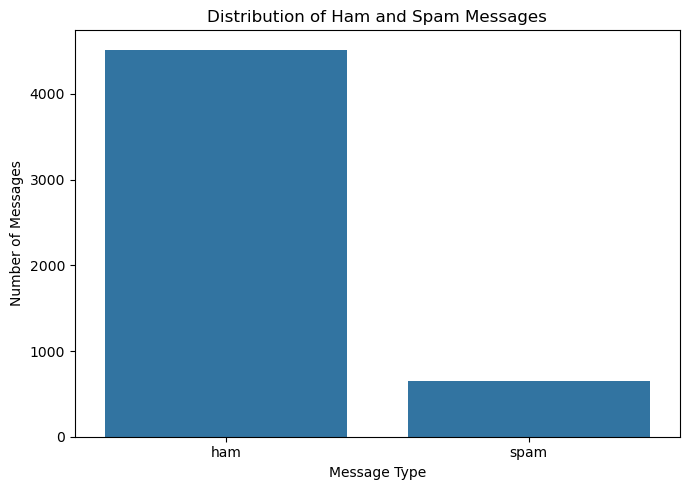

In [8]:
# Visualize the distribution of ham and spam messages

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.tight_layout()
plt.show()

### Class Distribution Observation

The dataset contains two message categories: ham and spam. The class distribution shows that legitimate messages make up the majority of the dataset, while spam messages represent a smaller portion.

This indicates that the dataset is imbalanced, so model evaluation should not rely only on accuracy. Precision, recall, and F1-score should also be considered when evaluating spam detection performance.


In [9]:
# Import NLTK tools for text preprocessing
import nltk
from nltk.corpus import stopwords

# Download English stopwords
nltk.download("stopwords")

# Load the English stopword list
stop_words = set(stopwords.words("english"))

print("Number of stopwords:", len(stop_words))

Number of stopwords: 198


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# Function to clean and preprocess text
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Split text into individual words
    words = text.split()

    # Remove common English stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Join the cleaned words back into a sentence
    return " ".join(words)

In [11]:
# Create a cleaned version of each message
df["clean_message"] = df["message"].apply(preprocess_text)

# Display original and cleaned messages
df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


## Text Preprocessing

Text data cannot be directly given to most machine learning algorithms, so the messages were first cleaned and standardized. Each message was converted to lowercase, punctuation and unnecessary characters were removed, and common English stopwords were excluded.

This preprocessing reduces unnecessary variation in the text and helps the machine learning models focus on words that are more useful for distinguishing spam messages from legitimate messages.


## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) is a technique used to convert text into numerical features that machine learning algorithms can process.

Term Frequency measures how frequently a word appears in a particular message, while Inverse Document Frequency reduces the importance of words that appear in many messages. As a result, words that are more useful for distinguishing between different types of messages receive greater importance.

In this project, TF-IDF is used to transform the cleaned SMS messages into numerical feature vectors before training the classification models.


In [12]:
# Create a TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000
)

# Convert cleaned messages into TF-IDF numerical features
X = tfidf.fit_transform(df["clean_message"])

# Target variable
y = df["label"]

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (5169, 5000)


In [13]:
# Convert message labels into numerical values
y = y.map({
    "ham": 0,
    "spam": 1
})

# Check the converted labels
print(y.value_counts())

label
0    4516
1     653
Name: count, dtype: int64


In [14]:
# Split the TF-IDF features into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4135
Testing samples: 1034


In [15]:
# Create the Multinomial Naive Bayes classifier
nb_model = MultinomialNB()

# Train the model using the TF-IDF training data
nb_model.fit(X_train, y_train)

# Predict labels for the test data
nb_predictions = nb_model.predict(X_test)

print("Multinomial Naive Bayes trained successfully.")

Multinomial Naive Bayes trained successfully.


In [16]:
# Create the Logistic Regression classifier
lr_model = LogisticRegression(
    max_iter=1000
)

# Train the model
lr_model.fit(X_train, y_train)

# Generate predictions
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [17]:
# Function to calculate classification metrics

def evaluate_classifier(actual, predicted):
    accuracy = accuracy_score(actual, predicted)
    precision = precision_score(actual, predicted)
    recall = recall_score(actual, predicted)
    f1 = f1_score(actual, predicted)

    return accuracy, precision, recall, f1

In [18]:
# Evaluate Multinomial Naive Bayes
nb_accuracy, nb_precision, nb_recall, nb_f1 = evaluate_classifier(
    y_test,
    nb_predictions
)

# Evaluate Logistic Regression
lr_accuracy, lr_precision, lr_recall, lr_f1 = evaluate_classifier(
    y_test,
    lr_predictions
)

# Display Naive Bayes results
print("Multinomial Naive Bayes")
print("----------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1-Score :", round(nb_f1, 4))

# Display Logistic Regression results
print("\nLogistic Regression")
print("-------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-Score :", round(lr_f1, 4))

Multinomial Naive Bayes
----------------------
Accuracy : 0.9691
Precision: 0.9901
Recall   : 0.7634
F1-Score : 0.8621

Logistic Regression
-------------------
Accuracy : 0.9526
Precision: 0.9881
Recall   : 0.6336
F1-Score : 0.7721


In [19]:
# Classification report for Multinomial Naive Bayes
print("Multinomial Naive Bayes Classification Report\n")

print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=["Ham", "Spam"]
    )
)

Multinomial Naive Bayes Classification Report

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       0.99      0.76      0.86       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034



In [20]:
# Classification report for Logistic Regression
print("Logistic Regression Classification Report\n")

print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=["Ham", "Spam"]
    )
)

Logistic Regression Classification Report

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.99      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.82      0.87      1034
weighted avg       0.95      0.95      0.95      1034



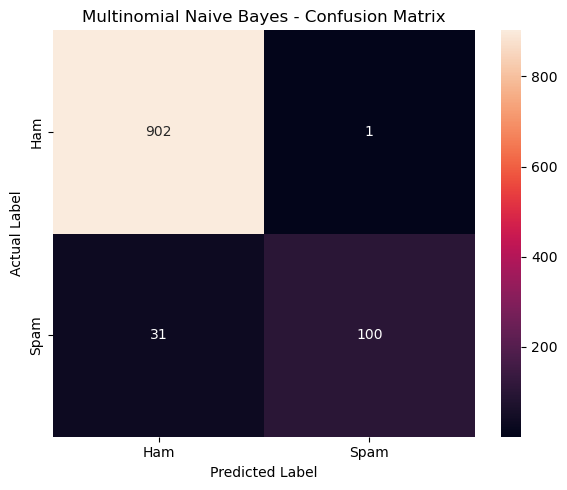

In [21]:
# Create confusion matrix for Naive Bayes
cm_nb = confusion_matrix(
    y_test,
    nb_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

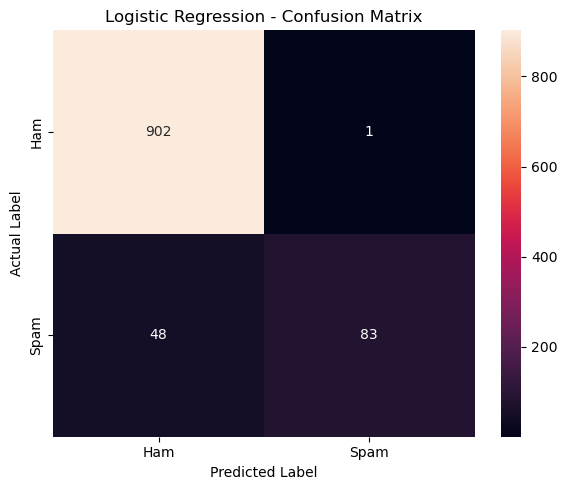

In [22]:
# Create confusion matrix for Logistic Regression
cm_lr = confusion_matrix(
    y_test,
    lr_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

## Why Is Recall Important in Spam Detection?

Recall is particularly important in spam detection because it measures how many of the actual spam messages are correctly identified by the model.

A false negative occurs when a spam message is incorrectly classified as a legitimate message. This can be problematic because unwanted or potentially harmful content may reach the user's inbox.

A model with higher recall is better at detecting a larger proportion of actual spam messages. However, recall should be considered together with precision because incorrectly classifying legitimate messages as spam can also cause problems.

Therefore, an effective spam detection system should aim for a good balance between precision and recall rather than relying only on accuracy.


## Best Model Selection

Both Multinomial Naive Bayes and Logistic Regression performed well on the SMS classification task. However, Multinomial Naive Bayes achieved better overall results.

Multinomial Naive Bayes achieved an accuracy of **97%**, while Logistic Regression achieved **95%**. For spam messages, Naive Bayes achieved a precision of **0.99**, recall of **0.76**, and F1-score of **0.86**. Logistic Regression achieved a precision of **0.99**, recall of **0.63**, and F1-score of **0.77**.

Multinomial Naive Bayes is therefore selected as the best-performing model. Its higher spam recall is particularly useful because it identifies a larger proportion of actual spam messages while maintaining very high precision.


In [ ]:
# Install WordCloud library if required
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud

In [ ]:
# Combine all cleaned spam messages into one text
spam_text = " ".join(
    df.loc[df["label"] == "spam", "clean_message"]
)

# Generate the spam word cloud
spam_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(spam_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Spam Messages")
plt.show()

In [ ]:
# Combine all cleaned ham messages into one text
ham_text = " ".join(
    df.loc[df["label"] == "ham", "clean_message"]
)

# Generate the ham word cloud
ham_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(ham_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Ham Messages")
plt.show()

## WordCloud Analysis

The word clouds provide a visual representation of frequently occurring words in spam and legitimate messages.

The spam word cloud highlights words that commonly appear in promotional, reward-related, or unsolicited messages. In comparison, the ham word cloud contains words that are more commonly associated with normal personal communication.

These visualizations provide an additional understanding of the vocabulary differences between spam and legitimate messages.


## Final Conclusion

This project developed a machine learning-based text classification system to distinguish spam messages from legitimate messages. The SMS Spam Collection dataset was cleaned and analyzed to understand the distribution of ham and spam messages.

Text preprocessing was performed by converting messages to lowercase, removing punctuation and unnecessary characters, and filtering out common English stopwords. TF-IDF was then used to transform the cleaned text into numerical features suitable for machine learning.

Two classification models were trained: Multinomial Naive Bayes and Logistic Regression. Both models performed well, but Multinomial Naive Bayes achieved better overall results.

Multinomial Naive Bayes achieved an accuracy of **97%**, with a spam precision of **0.99**, recall of **0.76**, and F1-score of **0.86**. Logistic Regression achieved an accuracy of **95%**, with a spam precision of **0.99**, recall of **0.63**, and F1-score of **0.77**.

Based on these results, **Multinomial Naive Bayes was selected as the best-performing model**. Its higher recall means that it was able to identify a larger proportion of actual spam messages compared with Logistic Regression.

The analysis also demonstrated why recall is an important metric for spam detection. Missing an actual spam message can allow unwanted or potentially harmful content to reach the user, so the ability to identify spam correctly is an important consideration.

Overall, this project demonstrates how NLP preprocessing, TF-IDF feature extraction, and machine learning classification can be combined to create an effective spam detection system.
